<a href="https://colab.research.google.com/github/elo-meriem/STAT-7220-Applied-Experimental-Design/blob/main/Assignments/Midterm-Exam/Midterm-Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "elo-meriem"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "elo-meriem" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Comparative Experiments"
today_dir = "Assignments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/elo-meriem/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
⚠️ WARNING: You are working in the instructor's repo, not your fork!
💡 Please fork the repo to your own account and update `github_username` above.
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments


# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 20, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to determine whether the type of grip material (plastic, rubber, silicone or meal ) has asignificant effect on the preceived comfort level of the video game controllers


**Question 2.** Specify the outcome variable

the comfort level rating which is a quantitave continuous variable measured on scale 1-10

**Question 3.** Specify the independent variable. What are some possible lurking variables?

IV: the grip material which is categorical variable with four levels (plastic, rubber, silicone, meal )

lurking variables:
- grip strengh
- hand size of the gamer
- Environmental conditions (humidity , temperature )
- prior preference or familiarity

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

the gamers are randomly assigned to each controller grip material group and each unit has an equal chance of being in one of the treatment groups.

**Question 5.** State the null and alternative hypotheses for this experiment.

𝐻0 ∶𝜇plastic=𝜇rubber=𝜇silicone=𝜇metal

𝐻1 ∶Atleast two group means differ substantially from each other

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Material  40 non-null     object 
 1   Comfort   40 non-null     float64
dtypes: float64(1), object(1)
memory usage: 772.0+ bytes
None
          mean       std
Material                
Metal     5.39  0.877433
Plastic   5.93  0.620125
Rubber    6.23  0.702456
Silicone  7.63  0.700872


Text(0, 0.5, 'Comfort')

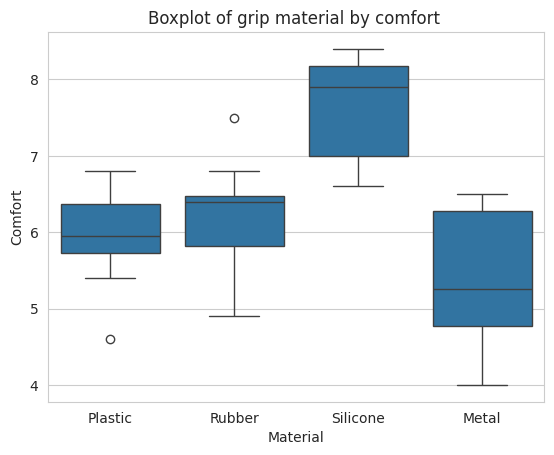

In [3]:
#%pip install openpyxl

## Import pandas ##
import pandas as pd

## Import Gamers.xlsx File ##
Gamers_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam/Video Game Controllers.xlsx")

## Integrity Check ##
print(Gamers_data.info())

#summury
summary_stats = Gamers_data.groupby('Material')['Comfort'].agg(['mean','std'])

print(summary_stats)

#####################################Data Visualization##################################
## Install matplotlib and seaborn ##
%pip install matplotlib seaborn
import seaborn as sns
import matplotlib.pyplot as plt

## Set a nice minimal style for plot ##
sns.set_style("whitegrid")

## Create boxplot using seaborn ##
sns.boxplot(x="Material",y="Comfort",data=Gamers_data)

## Add Title and Labels using matplotlib ##
plt.title("Boxplot of grip material by comfort ", loc='center')
plt.xlabel("Material")
plt.ylabel("Comfort")


As shown in both the table of summary statistics as well as the boxplots,we observe that the silicone has the highest mean of comfort level while the metal has the lowest

Looking at the table, metal (0.88) has the highest variability, which indicates slightly more disagreement among the gamers in their comfort ratings. In contrast, plastic (0.62) has the lowest variability, suggesting more consistent ratings among users.

Looking at the boxplots, we really don’t see any overlap between any pairwise comparison of the treatment groups.
This lends evidence toward the alternative hypothesis.


**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?

The residuals are normally distributed
based on the Q-Q plot, most points fall near the line with minimal deviation. thus we can conclude that the Q-Q plot gives evidence in support of normality assumption

Shapiro-Wilk Test P-Value:  0.3874>0.05 which also means that the assumption of normality is supported by the data.





               df  sum_sq   mean_sq          F        PR(>F)
C(Material)   3.0  27.387  9.129000  17.070642  4.616153e-07
Residual     36.0  19.252  0.534778        NaN           NaN


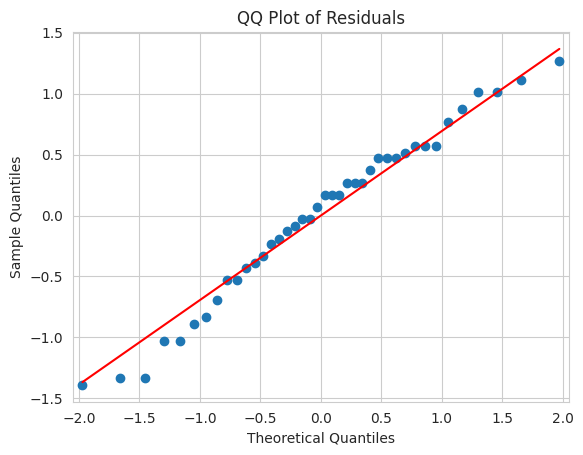

Shapiro-Wilk Test Statistic: 0.9710
Shapiro-Wilk Test P-Value: 0.3874
Fail to reject null hypothesis: Residuals are normally distributed.


In [4]:
###########  Building the one-way ANOVA model #######################################

## Install statsmodels.api ##
%pip install statsmodels

## Import statsmodels ##

import statsmodels.api as sm
from statsmodels.formula.api import ols

## Fit One-Way ANOVA Model ##
mod = ols("Comfort ~ C(Material)", data=Gamers_data).fit()

## Get the ANOVA table ##

aov_tab = sm.stats.anova_lm(mod,typ=1)

print(aov_tab)

########################## Assumption of normality using Q-Q Plot #########################################

## Install scipy package ##
%pip install scipy ##

## Import scipy ##
import scipy.stats as stats

## Extract Model Residuals ##
residuals = mod.resid

## Generate QQ plot using seaborn ##
sm.qqplot(residuals, line ='s')
plt.title("QQ Plot of Residuals")
plt.show()

####################Assumption of normality usuing Shapiro-wilk test ########################
## Perform Shapiro-Wilk Test of Normality ##
sw_test = stats.shapiro(residuals)
## Extract Test Stat and P-Value ##
sw_stat = sw_test.statistic
sw_pvalue = sw_test.pvalue
## Print Results ##
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print("Fail to reject null hypothesis: Residuals are normally distributed.")
else:
    print("Reject null hypothesis: Residuals are not normally distributed.")



**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?


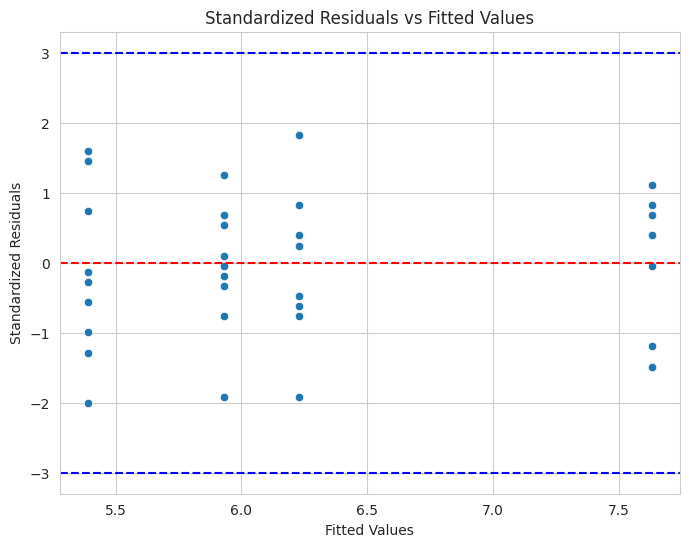

BP Test F-statistic: 0.684288131275624
BP Test F p-value: 0.5674916917969977
Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.


In [5]:

#test homegeneity of variance:

############################ Visual Method ##################################
## Obtain Standardized Residuals ##
standardized_residuals = mod.get_influence().resid_studentized_internal

## Get the fitted values ##
fitted_values = mod.fittedvalues

## Create the plot using seaborn ##
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

####################### The testing Method:  Bruesch-Pagan Test######################

## Import necessary function: ##
from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##
bp_test = het_breuschpagan(mod.resid,mod.model.exog)

## Extract F-statistic ##
f_statistic = bp_test[2]

## Extract its P-Value ##
f_p_value = bp_test[3]

print(f"BP Test F-statistic: {f_statistic}")
print(f"BP Test F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.")
else:
    print("Reject null hypothesis: Heteroscedasticity detected. Constant Variance not assumed.")


visual method:

- for each group mean (shown by the vertical lines), the residuals are mostly centered around 0
- there aren't any points greater than +3 or less than -3, which means that we are not observing any obvious outliers.
- the length of the vertical spread of the residuals for each group mean is relatively similar which indicates the constant variance.

we can  conclude that the constant variance assumption is reasonably supported by the data

The testing Method:  Bruesch-Pagan Test

because p-value:  0.567 > 0.05
we Fail to reject null hypothesis: Homoscedasticity detected. therfore  Constant Variance assumed.

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

 df  sum_sq   mean_sq          F        PR(>F)
C(Material)   3.0  27.387  9.129000  17.070642  4.616153e-07
Residual     36.0  19.252  0.534778        NaN           NaN

From our omnibus test, we can see that we have 𝐹(3,36) = 17.07 with an associated p-value 0.000000462 that is less than 𝛼 = 0.05. This indicates that the data more strongly support that alternative
hypothesis that at least two group means differ substantially from each other.



**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.



 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.54 0.3639 -0.3408 1.4208  False
  Metal   Rubber     0.84 0.0662 -0.0408 1.7208  False
  Metal Silicone     2.24    0.0  1.3592 3.1208   True
Plastic   Rubber      0.3 0.7958 -0.5808 1.1808  False
Plastic Silicone      1.7    0.0  0.8192 2.5808   True
 Rubber Silicone      1.4 0.0007  0.5192 2.2808   True
------------------------------------------------------


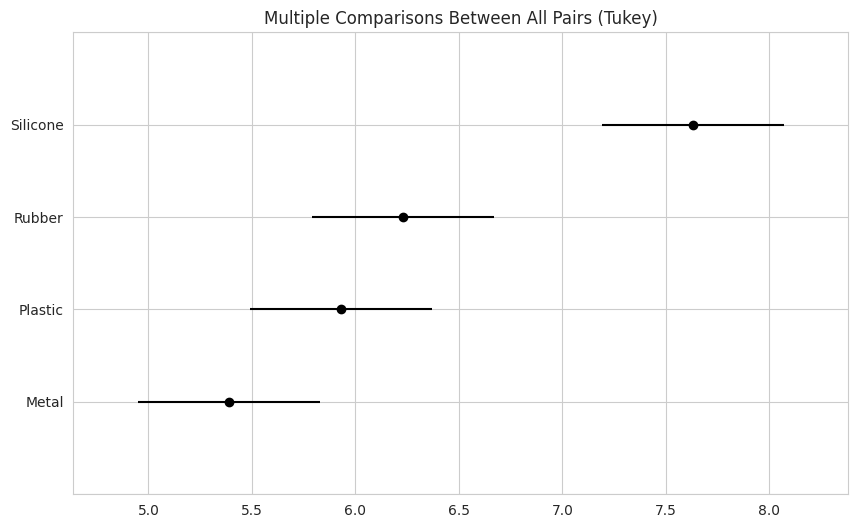

In [5]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=Gamers_data['Comfort'],
                                 groups=Gamers_data['Material'],
                                 alpha=0.05)

# Plot Tukey confidence intervals
tukey_result.plot_simultaneous()

# Print Tukey table
print(tukey_result)

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.

the results indicate that silicone is significantly more comfortable than metal, plastic and rubber. however, there are no statistically significant differences among metal, Plastic and rubber . This confirms the results observed in the exploratory analysis where silicone has the highest average comfort level

limitations:
- Sample Size: Only 10 prototypes per material were tested, which may limit the generalizability of the results.

- Ratings: Comfort was self-reported, which can introduce personal bias.

**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to determine whether the VR-based teaching method leads to more favorable attitudes toward elderly patients (measured by quiz scores) compared to the traditional teaching method, while accounting for students’ prior work experience with elderly individuals.

**Question 2.** Specify the outcome variable

the score on the 50 qquestions quiz , which is quantitative continous variable

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

IV: the teaching method, categorical variable with two levels (VR and traditional )

bloking factor: prior experience, categorical nominal variable with two level (yes/No)

lurking factors :
- years of experiences
- Prior knowlege or coursework about elderly care
- comfort level with VR methpd
- student motivation

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

A randomized block design is appropriate in this situation because it helps control for the potential confounding effect of prior experience on quiz scores. By forming blocks based on prior experience, we can compare the VR and traditional teaching methods fairly within each experience group.

A completely randomized design would not be suitable because it would fail to account for differences in prior experience, which could influence the results and introduce bias.

In other words, we assume that nursing students are not homogeneous with respect to prior experience. Therefore, we first divide the students into groups (blocks) based on their experience level and then randomly assign participants within each block to the different teaching methods.


**Question 5.** State the null and alternative hypotheses for this experiment.

H0:μ(vr)=μ(traditional)

H1:μ(vr)> μ(traditional)

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?


In [6]:
## Import Appropriate Libraries ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Import Data ##
Nursing_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam/Nursing VR Study.xlsx")

## Data Integrity Check ##
print(Nursing_data.info())

## Calculate Means and Standard Deviations
sum_stats = Nursing_data.groupby(['Experience','Method'])['Score'].agg(['mean','std'])

print(sum_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Method      40 non-null     object
 1   Experience  40 non-null     object
 2   Score       40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB
None
                                 mean       std
Experience          Method                     
No Prior Experience Traditional  30.7  4.691600
                    VR           37.3  7.916930
Prior Experience    Traditional  30.9  8.556349
                    VR           39.7  6.056218


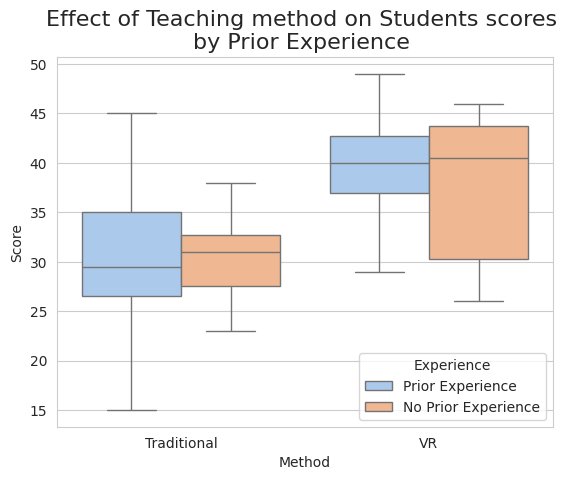

In [7]:
#visualization

sns.set_style("whitegrid")

sns.boxplot(
    data=Nursing_data,
    x='Method',
    y='Score',
    hue='Experience',
    palette='pastel' # Choose a color palette
)

## Step 3: Add labels and titles ##
plt.title("Effect of Teaching method on Students scores \nby Prior Experience ",
          loc='center',
          fontsize=16)

## Show the plot ##
plt.show()

Looking at the summary statistics, we can see that the average standard deviation is roughly 6.8 points. The difference between the VR and Traditional techniques is about 6.6 points for students with no prior experience and 8.8 points for students with prior experience, which corresponds to approximately 1 to 1.5 standard deviations. This suggests that there may be a potentially meaningful difference between the VR and traditional teaching methods.

the boxplot shows consistent patterns across experience groups, with VR scoring higher in both cases. The results indicate a clear separation between the VR and Traditional groups within each experience level, suggesting a substantial difference in outcomes.

In sum, the results of the descriptive analysis provide support for the alternative hypothesis that the VR teaching method leads to more favorable attitudes toward elderly patients compared to the traditional method.


**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

From the results of our visual and testing method of evaluating the normality assumption, we can see that the data support the assumption of normality given that:

The points in the QQ-plot all generally fall along the line bisecting the plot with little deviation, and
The p-value associated with the Shapiro-Wilk Test of Normality gives evidence for the null hypothesis of normality.


In [6]:
## Fit ANOVA Model ##

#fit the model:
ex_mod = ols("Score~Method+Experience",data=Nursing_data).fit()

## Obtain ANOVA Table ##

## Note, we use Type III SS so that way the Teaching method
## is evaluated after adjusting for prior experience ##

ex_tab = sm.stats.anova_lm(ex_mod,typ=3)

## Add Significance Column ##
ex_tab["Significance"] = np.where(ex_tab["PR(>F)"]<0.05,"Significant","Not Significant")

## Print Only Treatment & BMI Rows ##
print(ex_tab.loc[["Method","Experience"]])

            sum_sq   df          F    PR(>F)     Significance
Method       592.9  1.0  12.441048  0.001140      Significant
Experience    16.9  1.0   0.354619  0.555135  Not Significant


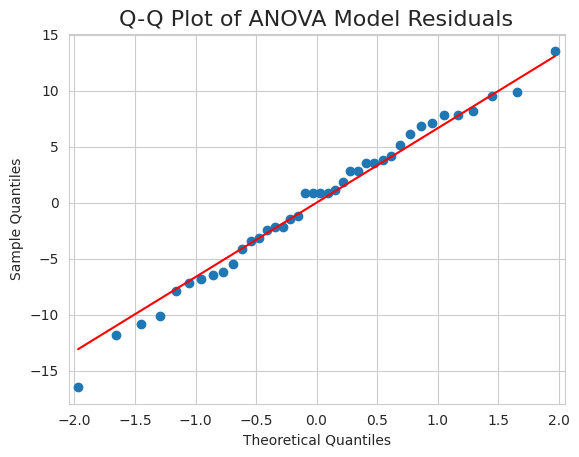

Shapiro-Wilk Test Statistic: 0.9869
Shapiro-Wilk Test P-Value: 0.9173
The residuals are normally distributed (fail to reject H0).


In [7]:
#Assumption checks:
## Assessing Normality ##

## Import scipy ##
import scipy.stats as stats

## Extract Model Residuals ##
ex_residuals = ex_mod.resid

## Generate QQ plot using seaborn ##
sm.qqplot(ex_residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals", fontsize=16)
plt.show()

## Perform Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(ex_residuals)
## Get Test Stat ##
shapiro_stat = shapiro_test.statistic
## Get P-Value ##
shapiro_pvalue = shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")
if shapiro_pvalue < 0.05:
    print("The residuals are not normally distributed (reject H0).")
else:
    print("The residuals are normally distributed (fail to reject H0).")

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

Here, we can also see that our visual and testing method support the assumption of constant variance of the residuals. This is because:

- In the scatterplot, the points are all randomly scattered about 0, which suggests that 0 may be a reasonable estimate for the mean of the residuals.

- Also in the scatterplot, the heights of the vertical lines are all approximately the same.

- The p-value associated with the B-P test statistic indicates that the data more strongly support the null hypothesis of constant variance.
Perfect! So since our assumption are reasonbly supported by the data, we can feel confident in interpreting the results:

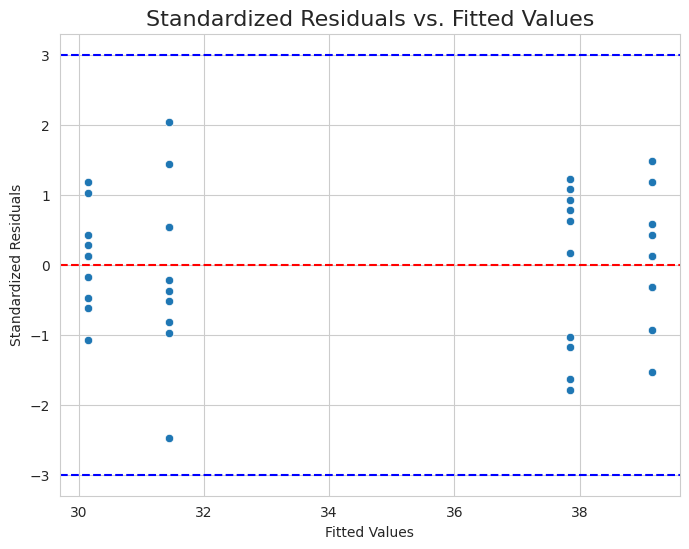

F-statistic: 0.19858503981404418
F p-value: 0.8207581702983743
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [8]:
## Constant Variance Check ##

## Scatterplot of Standardized Residuals to Fitted Values ##

## Obtain Standardized Residuals ##
standardized_residuals = ex_mod.get_influence().resid_studentized_internal

## Get the fitted values ##
fitted_values = ex_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##

## Import necessary function: ##
from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##
bp_test = het_breuschpagan(ex_mod.resid,ex_mod.model.exog)

## Extract F-statistic ##
f_statistic = bp_test[2]

## Extract its P-Value ##
f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?


In [9]:
## Print ANOVA Table Again ##

print(ex_tab.loc[["Method","Experience"]])


            sum_sq   df          F    PR(>F)     Significance
Method       592.9  1.0  12.441048  0.001140      Significant
Experience    16.9  1.0   0.354619  0.555135  Not Significant



Since F(1, 37) = 0.35, p = 0.555 > 0.05, we fail to reject the null hypothesis.

this suggests that having prior experience working with elderly patients does not appear to significantly affect the attitude scores, after adjusting for the teaching method.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.


Figure(1000x600)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
   group1   group2 meandiff p-adj lower   upper  reject
-------------------------------------------------------
Traditional     VR      7.7 0.001 3.3184 12.0816   True
-------------------------------------------------------


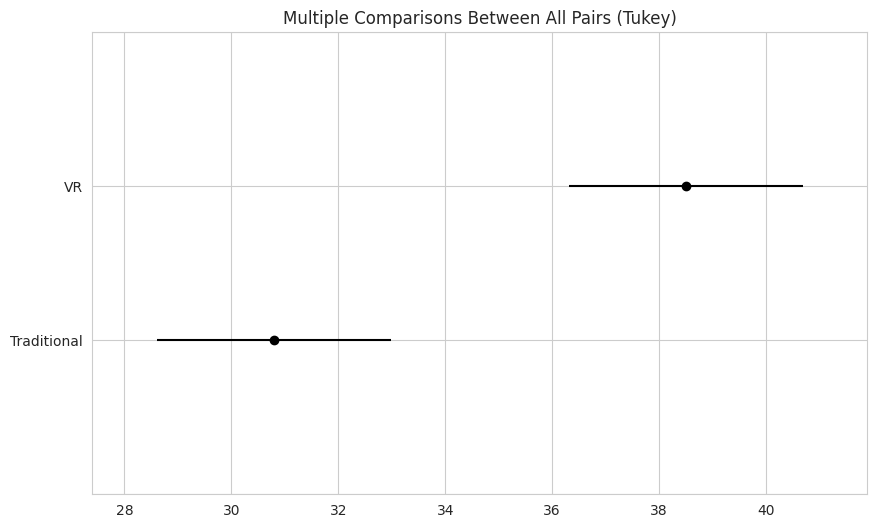

In [10]:
## Import pairwise_tukeyhsd function ##
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test  ##
tukey_result = pairwise_tukeyhsd(endog=Nursing_data['Score'], groups=Nursing_data['Method'],
                                 alpha=0.05)

## Print Tukey Visualization ##
print(tukey_result.plot_simultaneous())

print(tukey_result)


**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.





**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

**Question 2.** What is the purpose of post-hoc tests?

**Question 3.** Explain the difference between RBD and LSD.

**Question 4.** Explain why randomization is important in designing experiments.

**Question 5.** Explain why replication is important in designing experiments.